# Sliding-window decoding

A monolithic decoder consumes the detector history for an entire experiment at once.
`SlidingWindowDecoder` instead decodes overlapping time windows, commits corrections in the leading part of each window, and carries their effect into later windows.

This notebook uses qLDPC memory circuits, whose detector coordinates put time in the first coordinate.
For external circuits with a different convention, pass `detector_to_time` explicitly rather than relying on automatic coordinate inference.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import sinter

from qldpc import circuits, codes, decoders

NUM_WORKERS = max(1, min(4, (os.cpu_count() or 1) - 1))

## Build windowed tasks

Each tuple supplies the code, syndrome rounds per window, and stride.
The examples use a window size equal to a known exact surface-code distance and a stride of `distance // 2`, but those are benchmark choices rather than API requirements.


In [3]:
def code_label(code):
    known_distance = code.get_distance_if_known()
    suffix = f", {known_distance}" if known_distance is not None else ""
    return f"[[{len(code)}, {code.dimension}{suffix}]]"


def run_windowed_memory_experiments(
    decoder_specs: Sequence[tuple[codes.CSSCode, int, int]],
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-3, -2, 5)),
    num_windows: int = 5,
    max_shots: int = 20_000,
    max_errors: int = 100,
    **decoder_kwargs,
):
    tasks = []
    custom_decoders = {}

    for code_index, (code, window_size, stride) in enumerate(decoder_specs):
        num_rounds = num_windows * window_size
        parts = circuits.get_memory_experiment_parts(
            code,
            basis=None,
            num_rounds=num_rounds,
        )
        detectors_x = parts.detector_record.get_events(*parts.qubit_ids.checks_x)
        detectors_z = parts.detector_record.get_events(*parts.qubit_ids.checks_z)

        decoder_name = f"windowed_{code_index}"
        custom_decoders[decoder_name] = decoders.SlidingWindowDecoder(
            window_size,
            stride,
            (detectors_x, detectors_z),
            **decoder_kwargs,
        )

        for probability in error_rates:
            noise = circuits.DepolarizingNoiseModel(
                probability,
                include_idling_error=False,
            )
            tasks.append(
                sinter.Task(
                    circuit=(
                        parts.initialization + noise.noisy_circuit(parts.qec_cycle) + parts.readout
                    ),
                    decoder=decoder_name,
                    json_metadata={
                        "label": code_label(code),
                        "probability": probability,
                        "rounds": num_rounds,
                    },
                )
            )

    return sinter.collect(
        tasks=tasks,
        custom_decoders=custom_decoders,
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


def plot_windowed_error_rates(decoder_specs, **decoder_kwargs):
    stats = run_windowed_memory_experiments(decoder_specs, **decoder_kwargs)
    figure, axis = plt.subplots(figsize=(5.5, 4.2))
    markers = ("o", "s", "^", "D")
    sinter.plot_error_rate(
        ax=axis,
        stats=stats,
        x_func=lambda stat: stat.json_metadata["probability"],
        group_func=lambda stat: stat.json_metadata["label"],
        failure_units_per_shot_func=lambda stat: stat.json_metadata["rounds"],
        plot_args_func=lambda index, _curve_id: {
            "marker": markers[index % len(markers)],
        },
    )
    reference_rates = sorted({stat.json_metadata["probability"] for stat in stats})
    axis.plot(
        reference_rates,
        reference_rates,
        color="black",
        linestyle=":",
        label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
    )
    axis.loglog()
    axis.set_xlabel("physical error rate per operation")
    axis.set_ylabel("estimated logical error rate per round")
    axis.legend(loc="best")
    axis.grid(which="both", alpha=0.3)
    figure.tight_layout()
    return figure, axis

## Surface-code comparison

The detector subsets let each window decode the CSS X and Z sectors independently.
The short run is enough to exercise the workflow and compare small distances, but not to establish a threshold.


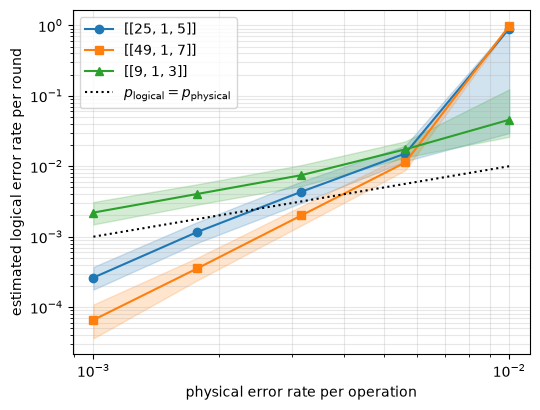

In [4]:
surface_specs = [
    (codes.SurfaceCode(distance, rotated=True), distance, max(1, distance // 2))
    for distance in (3, 5, 7)
]
plot_windowed_error_rates(surface_specs, with_MWPM=True)
plt.show()

## Check the dependence on experiment length

Sinter can express the failure probability per round for experiments of different lengths.
If the points settle near a common value, that is evidence that boundary effects are small over this range; a finite sampled curve does not prove the rate is exactly constant.


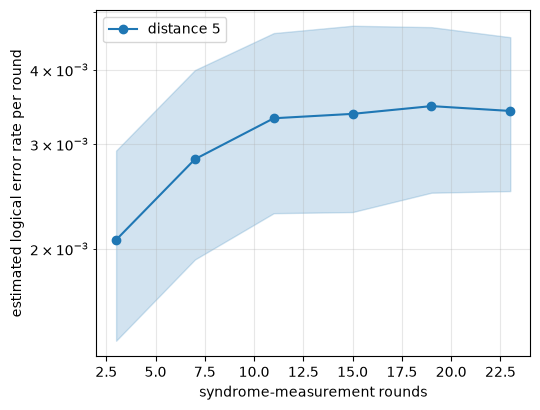

In [5]:
def run_length_sweep(
    code,
    *,
    window_size,
    stride,
    probability=3e-3,
    round_counts=tuple(range(3, 24, 4)),
    max_shots=20_000,
    max_errors=100,
    **decoder_kwargs,
):
    tasks = []
    custom_decoders = {}

    for num_rounds in round_counts:
        parts = circuits.get_memory_experiment_parts(
            code,
            basis=None,
            num_rounds=num_rounds,
        )
        detector_subsets = (
            parts.detector_record.get_events(*parts.qubit_ids.checks_x),
            parts.detector_record.get_events(*parts.qubit_ids.checks_z),
        )
        decoder_name = f"rounds_{num_rounds}"
        custom_decoders[decoder_name] = decoders.SlidingWindowDecoder(
            window_size,
            stride,
            detector_subsets,
            **decoder_kwargs,
        )
        noise = circuits.DepolarizingNoiseModel(
            probability,
            include_idling_error=False,
        )
        tasks.append(
            sinter.Task(
                circuit=(
                    parts.initialization + noise.noisy_circuit(parts.qec_cycle) + parts.readout
                ),
                decoder=decoder_name,
                json_metadata={"rounds": num_rounds},
            )
        )

    return sinter.collect(
        tasks=tasks,
        custom_decoders=custom_decoders,
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


surface_code = codes.SurfaceCode(5, rotated=True)
length_stats = run_length_sweep(
    surface_code,
    window_size=5,
    stride=2,
    with_MWPM=True,
)

figure, axis = plt.subplots(figsize=(5.5, 4.2))
sinter.plot_error_rate(
    ax=axis,
    stats=length_stats,
    x_func=lambda stat: stat.json_metadata["rounds"],
    group_func=lambda _stat: "distance 5",
    failure_units_per_shot_func=lambda stat: stat.json_metadata["rounds"],
    plot_args_func=lambda _index, _curve_id: {"marker": "o"},
)
axis.set_yscale("log")
axis.set_xlabel("syndrome-measurement rounds")
axis.set_ylabel("estimated logical error rate per round")
axis.legend(loc="best")
axis.grid(which="both", alpha=0.3)
figure.tight_layout()
plt.show()

For long computations, choose the window size, stride, and decoder together.
Larger overlaps use more history and more compute; smaller commit regions delay final decisions.
